In [1]:
# Cell 1: Generate synthetic sales dataset

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

n_rows = 10_000  # 10,000 sales records

categories = ['Electronics', 'Clothing', 'Food', 'Furniture', 'Sports']
regions = ['North', 'South', 'East', 'West']

start_date = datetime(2021, 1, 1)
end_date = datetime(2023, 12, 31)
date_range = (end_date - start_date).days

dates = [start_date + timedelta(days=random.randint(0, date_range))
         for _ in range(n_rows)]

# Sales amount influenced by category, region, and season (realistic)
def generate_sales(category, month):
    base = {'Electronics': 8000, 'Clothing': 3000, 'Food': 1500,
            'Furniture': 12000, 'Sports': 4000}
    seasonal_boost = 1.5 if month in [11, 12, 1] else 1.0  # winter boost
    noise = np.random.normal(0, 500)
    return max(100, round(base[category] * seasonal_boost + noise, 2))

date_list = dates
category_list = [random.choice(categories) for _ in range(n_rows)]
month_list = [d.month for d in date_list]

df = pd.DataFrame({
    'date': date_list,
    'category': category_list,
    'region': [random.choice(regions) for _ in range(n_rows)],
    'units_sold': np.random.randint(1, 50, size=n_rows),
    'discount_pct': np.round(np.random.uniform(0, 0.4, size=n_rows), 2),
    'sales_amount': [generate_sales(c, m) for c, m in zip(category_list, month_list)]
})

df.to_csv('sales_data.csv', index=False)
print(f"Dataset created: {df.shape}")
print(df.head())

Dataset created: (10000, 6)
        date     category region  units_sold  discount_pct  sales_amount
0 2021-08-17    Furniture   East          39          0.12      12260.53
1 2021-02-21     Clothing   West          29          0.10       3121.14
2 2022-07-18         Food   West          15          0.01       1328.68
3 2022-05-17     Clothing  North          43          0.11       3090.89
4 2022-04-03  Electronics   East           8          0.22       7302.07


=== BASIC INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          10000 non-null  datetime64[us]
 1   category      10000 non-null  str           
 2   region        10000 non-null  str           
 3   units_sold    10000 non-null  int64         
 4   discount_pct  10000 non-null  float64       
 5   sales_amount  10000 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 587.3 KB
None

=== MISSING VALUES ===
date            0
category        0
region          0
units_sold      0
discount_pct    0
sales_amount    0
dtype: int64

=== STATISTICAL SUMMARY ===
                             date    units_sold  discount_pct  sales_amount
count                       10000  10000.000000  10000.000000  10000.000000
mean   2022-07-03 09:41:28.320000     25.151500      0.200476   6425.913587

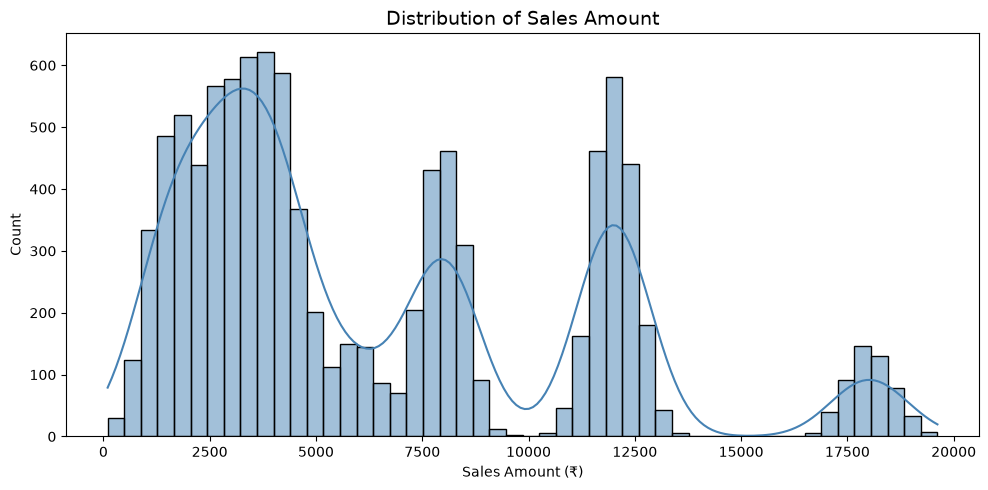

In [2]:
# Cell 2: EDA - Understand the data before modeling

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sales_data.csv', parse_dates=['date'])

print("=== BASIC INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

# Distribution of target variable
plt.figure(figsize=(10, 5))
sns.histplot(df['sales_amount'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Sales Amount', fontsize=14)
plt.xlabel('Sales Amount (₹)')
plt.tight_layout()
plt.savefig('sales_distribution.png')
plt.show()

In [3]:
# Cell 3: Feature Engineering
# Create useful numerical features from raw data

df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['year'] = df['date'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # 1 if weekend
df['is_festive'] = df['month'].isin([10, 11, 12]).astype(int)  # festive season

print("New features added:")
print(df[['date','month','quarter','day_of_week','is_weekend','is_festive']].head())

New features added:
        date  month  quarter  day_of_week  is_weekend  is_festive
0 2021-08-17      8        3            1           0           0
1 2021-02-21      2        1            6           1           0
2 2022-07-18      7        3            0           0           0
3 2022-05-17      5        2            1           0           0
4 2022-04-03      4        2            6           1           0


In [4]:
# Cell 4: Feature Selection and Encoding

# One-Hot Encoding: converts text categories to numbers
# e.g., category='Food' → category_Food=1, others=0
# ML models only understand numbers, not text

df_encoded = pd.get_dummies(df, columns=['category', 'region'], drop_first=False)

# Select features (X) and target (y)
feature_cols = ['units_sold', 'discount_pct', 'month', 'quarter',
                'day_of_week', 'year', 'is_weekend', 'is_festive',
                'category_Clothing', 'category_Electronics',
                'category_Food', 'category_Furniture', 'category_Sports',
                'region_East', 'region_North', 'region_South', 'region_West']

X = df_encoded[feature_cols]
y = df_encoded['sales_amount']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns:\n{feature_cols}")

Features shape: (10000, 17)
Target shape:   (10000,)

Feature columns:
['units_sold', 'discount_pct', 'month', 'quarter', 'day_of_week', 'year', 'is_weekend', 'is_festive', 'category_Clothing', 'category_Electronics', 'category_Food', 'category_Furniture', 'category_Sports', 'region_East', 'region_North', 'region_South', 'region_West']


In [5]:
# Cell 5: Split data into training and testing sets

from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
# random_state=42 ensures same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"\nModel will LEARN from {X_train.shape[0]} rows")
print(f"Model will be TESTED on {X_test.shape[0]} rows (never seen before)")

Training samples : 8,000
Testing samples  : 2,000

Model will LEARN from 8000 rows
Model will be TESTED on 2000 rows (never seen before)


In [6]:
# Cell 6: Model 1 - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # This is where learning happens

# Predict on test set
lr_predictions = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2   = r2_score(y_test, lr_predictions)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"MAE  : ₹{lr_mae:,.2f}")
print(f"RMSE : ₹{lr_rmse:,.2f}")
print(f"R²   : {lr_r2:.4f}")

=== LINEAR REGRESSION RESULTS ===
MAE  : ₹1,008.15
RMSE : ₹1,367.55
R²   : 0.9067


In [7]:
# Cell 7: Model 2 - Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# n_estimators = number of trees in the forest
# More trees = more accurate but slower
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)

print("=== RANDOM FOREST RESULTS ===")
print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

=== RANDOM FOREST RESULTS ===
MAE  : ₹420.03
RMSE : ₹521.50
R²   : 0.9864


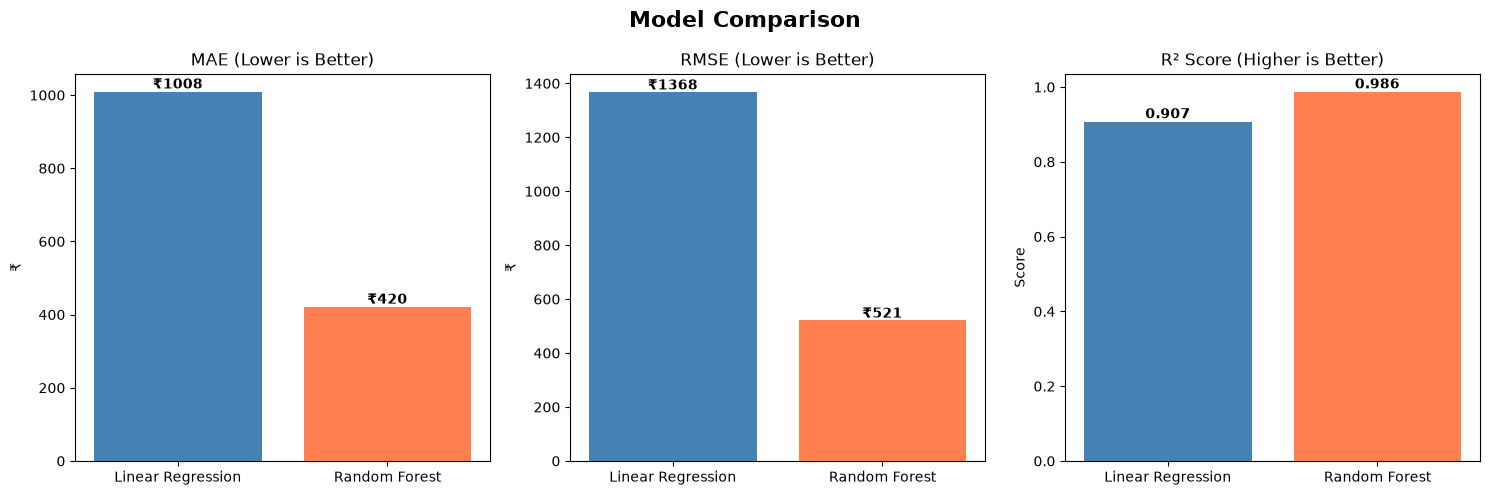

In [8]:
# Cell 8: Compare both models visually

models = ['Linear Regression', 'Random Forest']
mae_scores  = [lr_mae, rf_mae]
rmse_scores = [lr_rmse, rf_rmse]
r2_scores   = [lr_r2, rf_r2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE comparison (lower is better)
axes[0].bar(models, mae_scores, color=['steelblue', 'coral'])
axes[0].set_title('MAE (Lower is Better)')
axes[0].set_ylabel('₹')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 10, f'₹{v:.0f}', ha='center', fontweight='bold')

# RMSE comparison (lower is better)
axes[1].bar(models, rmse_scores, color=['steelblue', 'coral'])
axes[1].set_title('RMSE (Lower is Better)')
axes[1].set_ylabel('₹')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 10, f'₹{v:.0f}', ha='center', fontweight='bold')

# R² comparison (higher is better)
axes[2].bar(models, r2_scores, color=['steelblue', 'coral'])
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylabel('Score')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

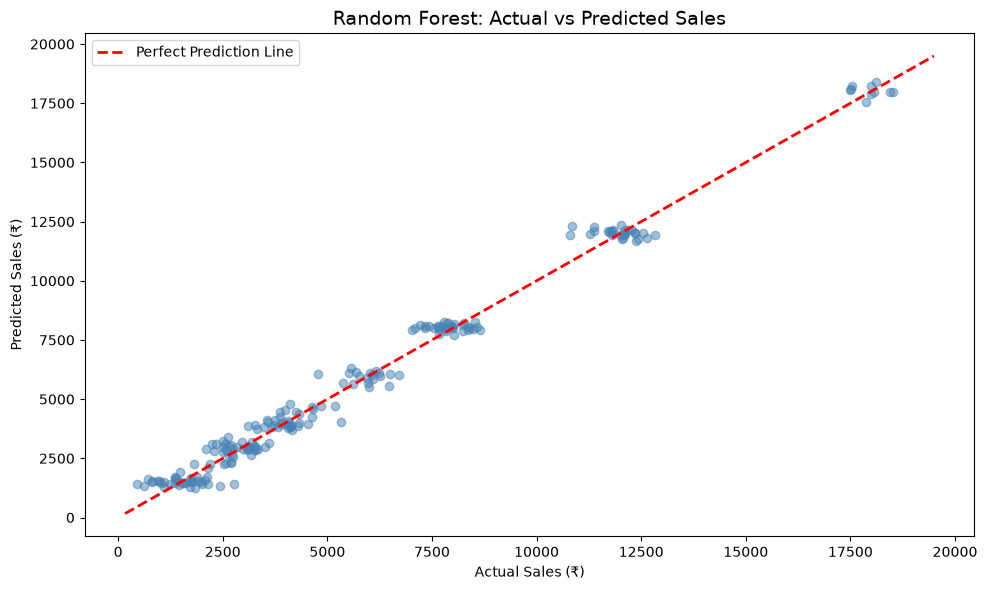

In [9]:
# Cell 9: Actual vs Predicted - visual check

plt.figure(figsize=(10, 6))
plt.scatter(y_test[:200], rf_predictions[:200], alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Sales (₹)')
plt.ylabel('Predicted Sales (₹)')
plt.title('Random Forest: Actual vs Predicted Sales', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

# If points cluster near the red line → model is accurate

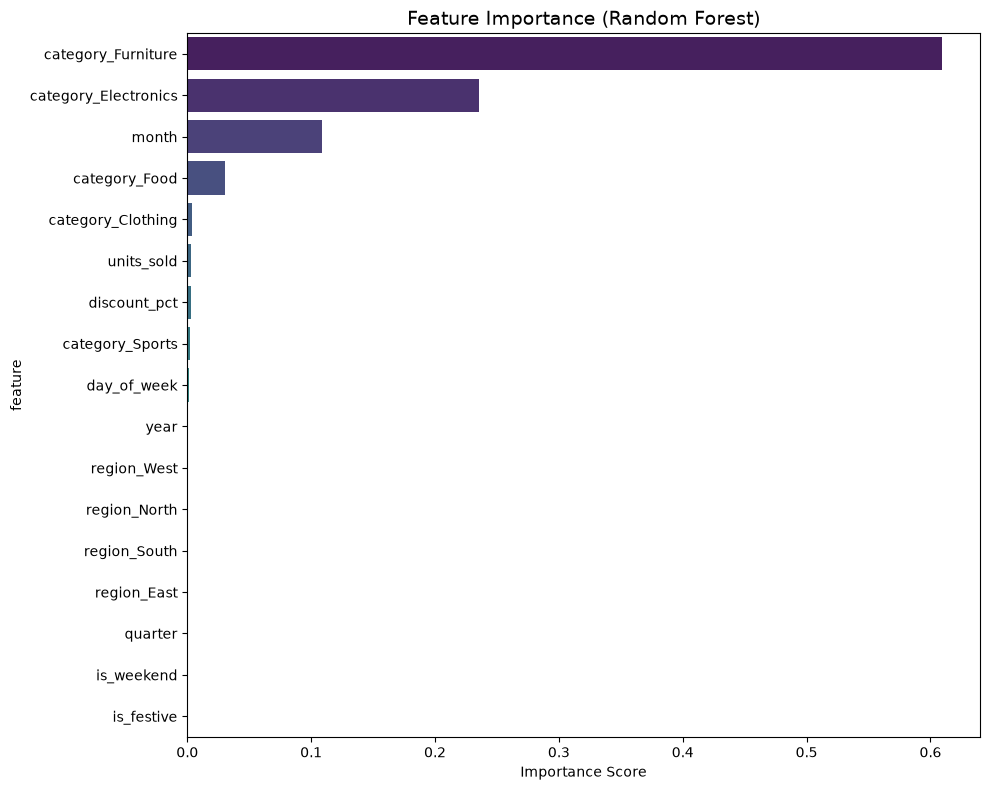


Top 5 most important features:
                 feature  importance
11    category_Furniture    0.609524
9   category_Electronics    0.235171
2                  month    0.108863
10         category_Food    0.030195
8      category_Clothing    0.003750


In [10]:
# Cell 10: Which features matter most?

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df,
            hue='feature', palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())

In [11]:
# Cell 11: Final Summary

print("=" * 55)
print("   PREDICTIVE SALES FORECAST - FINAL SUMMARY")
print("=" * 55)
print(f"\nDataset          : {df.shape[0]:,} sales records")
print(f"Features used    : {len(feature_cols)}")
print(f"Train/Test split : 80% / 20%")
print(f"\n{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 55)
print(f"{'Linear Regression':<25} ₹{lr_mae:>8,.0f} ₹{lr_rmse:>8,.0f} {lr_r2:>7.3f}")
print(f"{'Random Forest':<25} ₹{rf_mae:>8,.0f} ₹{rf_rmse:>8,.0f} {rf_r2:>7.3f}")
print("=" * 55)
print(f"\n✓ Best Model     : Random Forest")
print(f"✓ Top Feature    : {importance_df.iloc[0]['feature']}")
print(f"✓ Model predicts sales with R² = {rf_r2:.3f}")

   PREDICTIVE SALES FORECAST - FINAL SUMMARY

Dataset          : 10,000 sales records
Features used    : 17
Train/Test split : 80% / 20%

Model                            MAE       RMSE       R²
-------------------------------------------------------
Linear Regression         ₹   1,008 ₹   1,368   0.907
Random Forest             ₹     420 ₹     521   0.986

✓ Best Model     : Random Forest
✓ Top Feature    : category_Furniture
✓ Model predicts sales with R² = 0.986
